# Model Evaluation

**Goal:** Train and tune an XGBoost classifier using the reduced feature set identified in the feature-selection analysis, and generate predictions for the test set using the competition's ROC AUC metric.

**Workflow:**

0. Setup the work environment.
1. Prepare the model's feature set, including the engineered features and behavioral cluster.
2. Tune the XGBoost classifier using stratified cross-validation and Optuna.
3. Train the final model on the full training set and generate test predictions.
4. Inspect the Optuna results for potential future hyperparameter tuning.

## 0. Setup

### Libraries

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold

import optuna
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

from optuna.importance import get_param_importances

import matplotlib.pyplot as plt


### Data loading


In [2]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e8/train.csv
/kaggle/input/competitions/playground-series-s6e8/test.csv


In [3]:
df_train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e8/train.csv")

# Save the target separately and drop it along with the ID to simplify data preparation.
target = df_train["addicted_label"]
df_train = df_train.drop(["addicted_label", "id"], axis=1)

df_train

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No
...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No
691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No
691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN


In [4]:
df_test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e8/test.csv")

# Retain the test IDs for the submission file and drop them from the test features.
test_ids = df_test["id"]
df_test = df_test.drop(["id"], axis=1)

df_test

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...
296297,25.0,11.76,5.15,1.94,2.75,8.24,237.0,127.0,14.10,Male,NaN,NaN
296298,28.0,7.67,2.70,1.55,2.95,5.54,187.0,121.0,8.25,Male,Low,Yes
296299,33.0,5.27,1.84,0.20,2.44,8.29,96.0,73.0,6.57,Female,High,No
296300,NaN,NaN,1.25,0.52,0.71,6.27,57.0,38.0,7.19,Female,Low,Yes


### Helper functions

These functions are used to create the engineered features identified during the feature exploration and feature-selection analysis.


In [5]:
def safe_divide(num, den):
    """Elementwise division that returns NaN (not inf) when the denominator is 0."""
    return num / den.replace(0, np.nan)


def add_features(df):
    """Create the retained engineered features identified during feature exploration."""
    df = df.copy()

    # Relative usage
    df["social_media_share"] = safe_divide(df["social_media_hours"], df["daily_screen_time_hours"])
    df["gaming_share"] = safe_divide(df["gaming_hours"], df["daily_screen_time_hours"])
    df["work_study_share"] = safe_divide(df["work_study_hours"], df["daily_screen_time_hours"])

    # Differences
    df["weekend_screen_diff"] = df["weekend_screen_time"] - df["daily_screen_time_hours"]
    df["free_time_hours"] = 24 - df["daily_screen_time_hours"] - df["sleep_hours"] - df["work_study_hours"]

    # Additional behavioral feature
    df["leisure_bias"] = df["social_media_share"] + df["gaming_share"] - df["work_study_share"]

    return df


## 1. Data preparation

The selected engineered features are created for both the training and test sets. A behavioral cluster is then generated using the same preprocessing fitted on the training data before the final feature set is selected.


In [6]:
# Apply the same feature engineering to both datasets.
df_train = add_features(df_train)
df_test = add_features(df_test)

df_train.head()


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,social_media_share,gaming_share,work_study_share,weekend_screen_diff,free_time_hours,leisure_bias
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,NaN,NaN,NaN,NaN,NaN,NaN
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0.180905,NaN,0.507538,NaN,6.78,NaN
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,NaN,NaN,NaN,2.38,NaN,NaN
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,0.196262,0.221184,0.523364,2.24,5.37,-0.105919
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,0.166964,0.250893,0.174107,2.19,5.60,0.243750


In [7]:
cluster_cols = [
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "weekend_screen_time",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
]

# Fit imputation and scaling on the training data only so that the test set
# is transformed using the same preprocessing.
train_medians = df_train[cluster_cols].median()

train_cluster_data = df_train[cluster_cols].fillna(train_medians)
test_cluster_data = df_test[cluster_cols].fillna(train_medians)

scaler = StandardScaler().fit(train_cluster_data)
train_scaled = scaler.transform(train_cluster_data)
test_scaled = scaler.transform(test_cluster_data)

# Use the selected k=2 behavioral segmentation from the feature-selection analysis.
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10).fit(train_scaled)

df_train["behavior_cluster"] = kmeans.predict(train_scaled)
df_test["behavior_cluster"] = kmeans.predict(test_scaled)


### Final feature selection

Restricting the model to the compact feature set identified in the feature-selection analysis. The same features are selected from both the training and test sets.


In [8]:
selected_features = [
    "daily_screen_time_hours",
    "weekend_screen_time",
    "social_media_hours",
    "app_opens_per_day",
    "notifications_per_day",
    "social_media_share",
    "work_study_share",
    "gaming_share",
    "leisure_bias",
    "work_study_hours",
    "behavior_cluster",
    "age",
    "free_time_hours",
    "sleep_hours",
    "gaming_hours",
    "weekend_screen_diff",
]

df_train = df_train[selected_features]
df_test = df_test[selected_features]

df_train.head()


,daily_screen_time_hours,weekend_screen_time,social_media_hours,app_opens_per_day,notifications_per_day,social_media_share,work_study_share,gaming_share,leisure_bias,work_study_hours,behavior_cluster,age,free_time_hours,sleep_hours,gaming_hours,weekend_screen_diff
0,NaN,8.63,1.83,38.0,122.0,NaN,NaN,NaN,NaN,2.11,0,24.0,NaN,7.46,1.59,NaN
1,5.97,NaN,1.08,19.0,76.0,0.180905,0.507538,NaN,NaN,3.03,0,19.0,6.78,8.22,NaN,NaN
2,5.09,7.47,NaN,60.0,134.0,NaN,NaN,NaN,NaN,NaN,0,18.0,NaN,6.25,NaN,2.38
3,6.42,8.66,1.26,94.0,112.0,0.196262,0.523364,0.221184,-0.105919,3.36,0,21.0,5.37,8.85,1.42,2.24
4,11.20,13.39,1.87,NaN,NaN,0.166964,0.174107,0.250893,0.243750,1.95,1,26.0,5.60,5.25,2.81,2.19


## 2. Model tuning

Optuna is used to tune the XGBoost hyperparameters using 5-fold stratified cross-validation. Each fold uses early stopping to determine the effective number of boosting rounds, while ROC AUC is used as the optimization metric to match the competition metric.


In [9]:
N_SPLITS = 5
kf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)


def objective(trial):
    params = {
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.005, 0.05, log=True
        ),
        "max_depth": trial.suggest_int("max_depth", 5, 12),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-8, 1.0, log=True
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-8, 1.0, log=True
        ),
        "min_child_weight": trial.suggest_int(
            "min_child_weight", 3, 15
        ),
    }

    fold_scores = []
    best_iters = []

    for train_idx, val_idx in kf.split(df_train, target):
        X_tr, X_val = df_train.iloc[train_idx], df_train.iloc[val_idx]
        y_tr, y_val = target.iloc[train_idx], target.iloc[val_idx]

        # Keep n_estimators high and let early stopping determine the
        # effective number of boosting rounds for each fold.
        model = XGBClassifier(
            **params,
            n_estimators=10000,
            objective="binary:logistic",
            random_state=42,
            early_stopping_rounds=150,
            eval_metric="auc",
        )

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        preds = model.predict_proba(X_val)[:, 1]
        fold_scores.append(roc_auc_score(y_val, preds))
        best_iters.append(model.best_iteration)

    # Store the average best iteration so it can be reused for the final
    # full-data fit without running early stopping again.
    trial.set_user_attr(
        "avg_best_iteration",
        int(np.mean(best_iters))
    )

    return float(np.mean(fold_scores))


In [10]:
study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=15)

[I 2026-09-14 12:32:22,437] A new study created in memory with name: no-name-f054962e-63c1-4210-ba86-a67a4b88675f
[I 2026-09-14 13:32:58,672] Trial 0 finished with value: 0.9643942275226312 and parameters: {'learning_rate': 0.00747278108981531, 'max_depth': 9, 'subsample': 0.7448015201952096, 'colsample_bytree': 0.8259616372654413, 'reg_alpha': 0.0017950657277451508, 'reg_lambda': 4.091164059865458e-08, 'min_child_weight': 9}. Best is trial 0 with value: 0.9643942275226312.
[I 2026-09-14 14:39:25,988] Trial 1 finished with value: 0.9645670389688661 and parameters: {'learning_rate': 0.006305765703197343, 'max_depth': 7, 'subsample': 0.8353935302941786, 'colsample_bytree': 0.7619224537979808, 'reg_alpha': 0.002798086622803909, 'reg_lambda': 0.0028895703309144713, 'min_child_weight': 3}. Best is trial 1 with value: 0.9645670389688661.
[I 2026-09-14 15:35:18,193] Trial 2 finished with value: 0.9637968615459311 and parameters: {'learning_rate': 0.00736444948495936, 'max_depth': 5, 'subsampl

In [11]:
print(study.best_params)
print(study.best_value)
print("avg best iteration:", study.best_trial.user_attrs["avg_best_iteration"])

{'learning_rate': 0.01906594952033582, 'max_depth': 6, 'subsample': 0.9270609004524326, 'colsample_bytree': 0.6122217971771474, 'reg_alpha': 1.6068230521858985e-06, 'reg_lambda': 1.2471094466994387e-07, 'min_child_weight': 4}
0.9649986661459373
avg best iteration: 7431


## 3. Final model training and predictions

The best hyperparameters and the average best iteration identified during cross-validation are used to train the final classifier on the full training set. Predictions are then generated for the test set and saved in the required submission format.


In [12]:
best_n_estimators = study.best_trial.user_attrs["avg_best_iteration"]

# Train the best model using the selected hyperparameters.
best_model = XGBClassifier(
    **study.best_params,
    n_estimators=best_n_estimators,
    objective="binary:logistic",
    random_state=42,
)

best_model.fit(df_train, target)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6122217971771474, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01906594952033582,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=4, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=7431, n_jobs=None,
              num_parallel_tree=None, ...)

In [13]:
# Generate predictions for the test set.
predict = best_model.predict_proba(df_test)[:, 1]

In [14]:
# Generate the submission CSV with predictions for the competition.
output = pd.DataFrame({
    "id": test_ids,
    "addicted_label": predict
}).to_csv("output.csv", index=False)

## 4. Inspect Optuna results for future parameter tuning

The completed Optuna study is inspected to understand which hyperparameters contributed most to the optimization results and to identify potential directions for future tuning.


### Parameter importance

Optuna's parameter importance is used to identify which hyperparameters contributed most to the variation in the objective value.

In [15]:
importance = get_param_importances(study)

for param, score in importance.items():
    print(f"{param}: {score:.3f}")


colsample_bytree: 0.644
max_depth: 0.166
subsample: 0.110
learning_rate: 0.040
min_child_weight: 0.023
reg_lambda: 0.018
reg_alpha: 0.000


### Parameter relationships

The trial results are collected into a dataframe and the correlation between each parameter and the mean cross-validation AUC is examined.

In [16]:
df_study = study.trials_dataframe()

trial_columns = [
    "value",
    "params_max_depth",
    "params_colsample_bytree",
    "params_learning_rate",
    "params_subsample",
    "params_min_child_weight",
    "params_reg_lambda",
    "params_reg_alpha",
    "user_attrs_avg_best_iteration",
]

df_study = df_study[trial_columns].sort_values(by="value", ascending=False)


In [17]:
df_study.corr()["value"].sort_values()


params_colsample_bytree         -0.903659
params_max_depth                -0.732073
params_reg_lambda               -0.570995
params_learning_rate            -0.170975
params_min_child_weight          0.249836
params_reg_alpha                 0.370720
user_attrs_avg_best_iteration    0.412783
params_subsample                 0.455796
value                            1.000000
Name: value, dtype: float64

### Parameter vs. validation AUC

Scatter plots are used to visualize how each hyperparameter relates to the mean cross-validation AUC and to identify promising regions for a future tuning run.

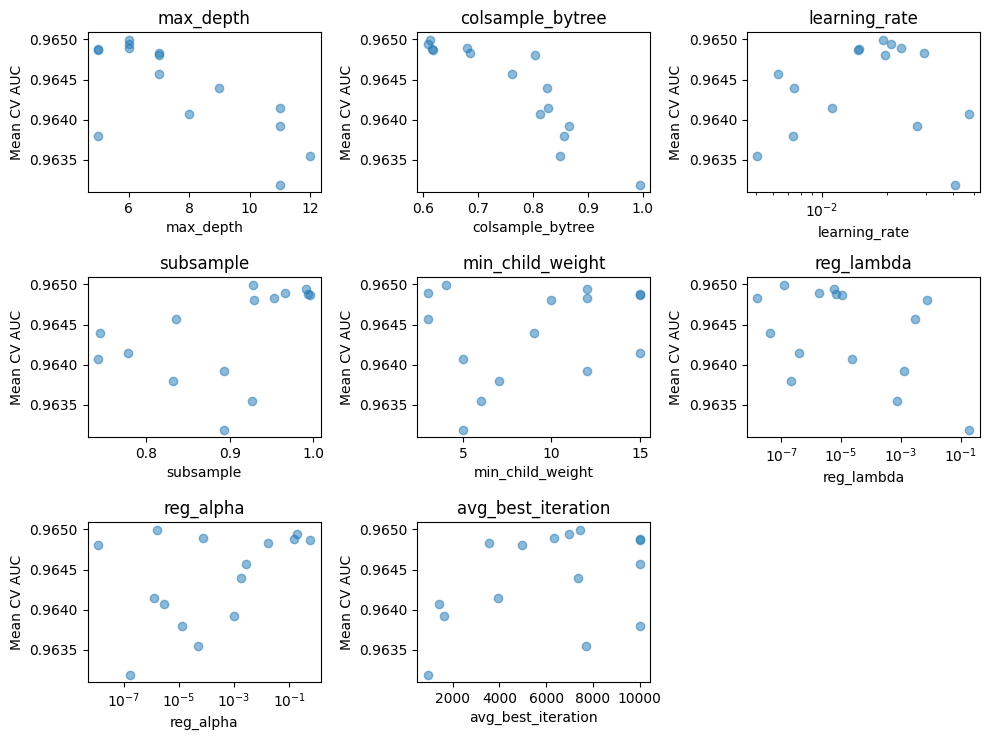

In [18]:
param_cols = [param for param in trial_columns if param != "value"]

log_params = [
    "params_learning_rate",
    "params_reg_alpha",
    "params_reg_lambda",
]

n_cols = 3
n_rows = (len(param_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10, 2.5 * n_rows)
)

axes = axes.flatten()

for ax, param in zip(axes, param_cols):
    ax.scatter(
        df_study[param],
        df_study["value"],
        alpha=0.5
    )

    if param in log_params:
        ax.set_xscale("log")

    label = param.replace("params_", "").replace("user_attrs_", "")
    ax.set_xlabel(label)
    ax.set_ylabel("Mean CV AUC")
    ax.set_title(label)

# Hide unused plots.
for ax in axes[len(param_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()
